# Research Question 3: County Demographics and Pennsylvania's Democratic Vote-Share Decline (Demographics-Only Model)

Analysis workflow: load the merged county-level dataset, check multicollinearity among the demographic predictors, standardize them, fit a Ridge regression with leave-one-out cross-validation to select the penalty parameter, and report both in-sample and honest out-of-sample fit.

Text/sentiment predictors (crime, immigration, abortion, economy coverage tone) are deferred to a later update -- this notebook covers the demographics-only model reported in the Q3 write-up.

## 1. Imports and data load

Loads the same 67-county Pennsylvania dataset used for Questions 1 and 2, now merged with six county-level demographic variables from the American Community Survey.

In [2]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 67-county PA dataset with demvoteshare_change + demographic variables merged in
df = pd.read_csv("C:/Users/mutch/Democratic_Voter_Shift/data/processed/election_demo_merged_q3.csv")

OUTCOME = "demvoteshare_change"
DEMO_VARS = [
    "pct_bachelor_plus",
    "median_hh_income",
    "pct_white",
    "pct_poverty",
    "pct_unemployed",
    "pct_foreignborn",
]

df_model = df[["county", OUTCOME] + DEMO_VARS].dropna()
print(f"Counties in model: {len(df_model)} of {len(df)}")
df_model.head()

Counties in model: 67 of 67


,county,demvoteshare_change,pct_bachelor_plus,median_hh_income,pct_white,pct_poverty,pct_unemployed,pct_foreignborn
0,Adams,0.005136,25.8,84092.0,88.9,8.2,3.4,3.7
1,Allegheny,0.000543,45.8,78548.0,76.1,11.5,5.0,6.6
2,Armstrong,-0.002106,19.0,65008.0,95.2,11.8,4.3,0.7
3,Beaver,-0.012843,28.7,71089.0,86.9,9.9,5.3,1.9
4,Bedford,-0.004397,16.1,59992.0,95.5,11.6,3.9,1.2


## 2. Variance inflation factor (VIF) check

Diagnostic, not a filtering step -- income, education, and poverty are structurally correlated at the county level, so several predictors are expected to show VIF well above the conventional 5-10 multicollinearity threshold. This is the direct motivation for using Ridge rather than ordinary least squares: with n = 67 and correlated predictors, OLS coefficients would be unstable, while Ridge shrinks correlated predictors together in a stable way.

In [3]:
X_raw = df_model[DEMO_VARS]

vif_table = pd.DataFrame({
    "variable": DEMO_VARS,
    "VIF": [variance_inflation_factor(X_raw.values, i) for i in range(X_raw.shape[1])],
}).sort_values("VIF", ascending=False)

print(vif_table.to_string(index=False))

         variable        VIF
        pct_white 176.079521
 median_hh_income 175.463820
      pct_poverty  42.205980
pct_bachelor_plus  34.610463
   pct_unemployed  19.622708
  pct_foreignborn  16.935859


## 3. Standardize predictors

Ridge's penalty term is scale-dependent, so every predictor is z-scored (mean 0, standard deviation 1) before fitting. This also makes the resulting coefficients directly comparable in magnitude to one another.

In [4]:
y = df_model[OUTCOME].values

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
X = pd.DataFrame(X, columns=DEMO_VARS, index=X_raw.index)
X.head()

,pct_bachelor_plus,median_hh_income,pct_white,pct_poverty,pct_unemployed,pct_foreignborn
0,-0.059234,0.914154,0.243471,-1.255359,-1.123968,-0.070021
1,2.085995,0.517550,-0.943572,-0.057948,0.088199,0.711877
2,-0.788612,-0.451067,0.827719,0.050908,-0.442124,-0.878880
3,0.251824,-0.016048,0.057996,-0.638511,0.315480,-0.555336
4,-1.099670,-0.809899,0.855541,-0.021663,-0.745166,-0.744070


## 4. Fit RidgeCV with leave-one-out cross-validation

`RidgeCV` searches a grid of 100 log-spaced alpha candidates (0.01 to 10,000) and picks whichever minimizes prediction error. Leave-one-out CV is used instead of standard k-fold because k-fold estimates are unstable at n = 67 -- LOOCV holds out each county one at a time, refits on the other 66, and averages the error across all 67 rounds.

In [5]:
ALPHA_GRID = np.logspace(-2, 4, 100)

loo = LeaveOneOut()
ridge_cv = RidgeCV(alphas=ALPHA_GRID, cv=loo, scoring="neg_mean_squared_error")
ridge_cv.fit(X, y)

print(f"Selected alpha (lambda): {ridge_cv.alpha_:.4f}")

Selected alpha (lambda): 9.3260


## 5. Standardized coefficients

Because every predictor was z-scored in Step 3, these coefficients are directly comparable in magnitude -- the largest-magnitude coefficient is the strongest driver in the model, regardless of sign.

In [6]:
coef_table = pd.DataFrame({
    "variable": DEMO_VARS,
    "standardized_coef": ridge_cv.coef_,
}).sort_values("standardized_coef", key=abs, ascending=False)

print(coef_table.to_string(index=False))

         variable  standardized_coef
   pct_unemployed          -0.004297
  pct_foreignborn          -0.003178
      pct_poverty          -0.001493
pct_bachelor_plus           0.001129
 median_hh_income          -0.001127
        pct_white           0.000947


## 6. Model fit: in-sample vs. honest out-of-sample (LOOCV)

In-sample R² reflects how well the model fits data it has already seen, and will run higher than the true generalization performance. LOOCV R² and RMSE predict each county from a model that never saw that county during fitting -- this is the number to report as the primary result.

In [7]:
y_pred_in = ridge_cv.predict(X)
ss_res = np.sum((y - y_pred_in) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2_in = 1 - ss_res / ss_tot

y_pred_loo = cross_val_predict(RidgeCV(alphas=[ridge_cv.alpha_]), X, y, cv=loo)
ss_res_loo = np.sum((y - y_pred_loo) ** 2)
r2_loo = 1 - ss_res_loo / ss_tot
rmse_loo = np.sqrt(np.mean((y - y_pred_loo) ** 2))

print(f"In-sample R^2:            {r2_in:.3f}")
print(f"LOOCV R^2 (out-of-sample): {r2_loo:.3f}")
print(f"LOOCV RMSE:                {rmse_loo:.5f}")

In-sample R^2:            0.569
LOOCV R^2 (out-of-sample): 0.479
LOOCV RMSE:                0.00721


## 7. Coefficient chart (Figure 8)

Horizontal bar chart of the six standardized coefficients, ranked by magnitude. Teal marks a positive association with Democratic vote-share change; rust marks a negative one.

C:\Users\mutch\AppData\Local\Temp\ipykernel_18692\127370798.py:34: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  pio.write_image(fig, "C:/Users/mutch/Democratic_Voter_Shift/output/ridge_q3_coefficients.png")


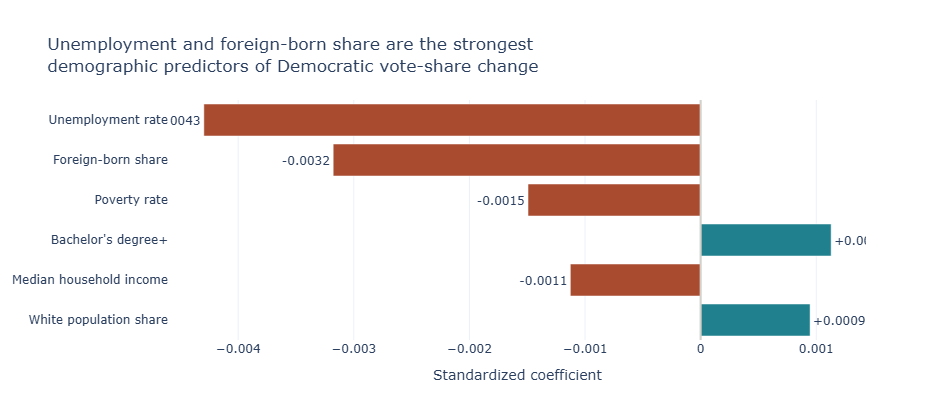

In [8]:
label_map = {
    "pct_unemployed": "Unemployment rate",
    "pct_foreignborn": "Foreign-born share",
    "pct_poverty": "Poverty rate",
    "pct_bachelor_plus": "Bachelor's degree+",
    "median_hh_income": "Median household income",
    "pct_white": "White population share",
}
chart_df = coef_table.copy()
chart_df["label"] = chart_df["variable"].map(label_map)
chart_df = chart_df.sort_values("standardized_coef", key=abs, ascending=True)
colors = ["#A84B2F" if v < 0 else "#20808D" for v in chart_df["standardized_coef"]]

fig = go.Figure(go.Bar(
    x=chart_df["standardized_coef"],
    y=chart_df["label"],
    orientation="h",
    marker_color=colors,
    text=[f"{v:+.4f}" for v in chart_df["standardized_coef"]],
    textposition="outside",
))
fig.update_layout(
    title="Unemployment and foreign-born share are the strongest<br>demographic predictors of Democratic vote-share change",
    xaxis_title="Standardized coefficient",
    template="plotly_white",
    height=420,
    width=750,
    showlegend=False,
)
fig.add_vline(x=0, line_color="#D4D1CA")

#save figure
import plotly.io as pio
pio.write_image(fig, "C:/Users/mutch/Democratic_Voter_Shift/output/ridge_q3_coefficients.png")

fig.show()


## 8. Save outputs

Predicted values and the coefficient table are saved for use in the Q3 write-up's tables and figures.

In [9]:
df_model["ridge_predicted"] = y_pred_in
df_model.to_csv("ridge_q3_predictions.csv", index=False)
coef_table.to_csv("ridge_q3_coefficients.csv", index=False)
print("Saved: ridge_q3_predictions.csv, ridge_q3_coefficients.csv")

Saved: ridge_q3_predictions.csv, ridge_q3_coefficients.csv
